# Titanic Surival Prediction with Logistic Regression from Scratch

---

## Goal

---

Build and understand a complete binary logistic regression workflow
using only NumPy and pandas. The implementation includes:
- data preparation
- train/test splitting
- feature standardization
- sigmoid activation
- binary cross-entropy loss
- gradient descent optimization
- prediction and evaluation

## 2. Imports and Configurations

---

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path().resolve().parents[1]
SRC_PATH = PROJECT_ROOT / "src"

sys.path.append(str(SRC_PATH))

from ml_engineering.data.preprocessing import (
	train_test_split_numpy,
	standardize_data,
)

from ml_engineering.models.logistic_regression import LogisticRegressionScratch
from ml_engineering.evaluation.metrics import accuracy, precision, recall, f1_score, confusion_matrix

In [2]:

DATA_PATH = "../../data/raw/titanic.csv"

TARGET_COLUMN = "survived"

TEST_SIZE = 0.2
RANDOM_STATE = 42

## 3. Load Dataset

---


In [3]:
df = pd.read_csv(DATA_PATH)

## 4. Prepare feature and targets

---
Split the dataset into input features (`X`) and target labels (`y`).

In [4]:
y = df[TARGET_COLUMN]
X = df.drop(columns=[TARGET_COLUMN])

# 5 Train Test Split

---

Split in Training and Testing set


In [5]:
X_train, X_test, y_train, y_test = train_test_split_numpy(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)


In [6]:
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (710, 7)
X_test shape: (177, 7)
y_train shape: (710,)
y_test shape: (177,)


## 6. Feature Scaling

---

Continuous numerical features are standardized using costum standardization function to improve optimization stability and model performance.

In [7]:
continuous_features = ["age", "fare", "family_size"]

X_train[continuous_features], X_test[continuous_features] = (
    standardize_data(
        X_train[continuous_features],
        X_test[continuous_features],
    )
)

In [8]:
X_train.describe()

,sex,age,family_size,fare,1st_class,2nd_class,3rd_class
count,710.000000,7.100000e+02,7.100000e+02,7.100000e+02,710.000000,710.000000,710.000000
mean,0.646479,4.003058e-17,-4.503440e-17,5.504204e-17,0.230986,0.212676,0.556338
std,0.478400,1.000000e+00,1.000000e+00,1.000000e+00,0.421761,0.409489,0.497166
min,0.000000,-2.068603e+00,-5.545847e-01,-6.916341e-01,0.000000,0.000000,0.000000
25%,0.000000,-6.487794e-01,-5.545847e-01,-5.156841e-01,0.000000,0.000000,0.000000
50%,1.000000,-6.866767e-02,-5.545847e-01,-3.707235e-01,0.000000,0.000000,1.000000
75%,1.000000,5.839581e-01,4.565179e-02,1.203649e-03,0.000000,0.000000,1.000000
max,1.000000,3.266975e+00,5.447780e+00,1.068304e+01,1.000000,1.000000,1.000000


## 7. Train Logistic Regression Model

---


In [9]:
model = LogisticRegressionScratch(n_iterations=1000, threshold=0.4)
model.fit(X_train, y_train)

In [10]:
print(f"Final loss: {model.losses[-1]:.4f}")

Final loss: 0.5290


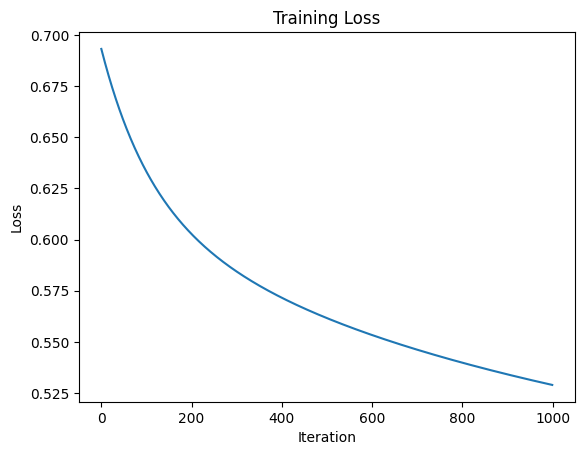

In [11]:
plt.plot(model.losses)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

## 8. Make Predictions

---

In [12]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

## 9. Model Evaluation

---


In [13]:
accuracy_value = accuracy(y_test, y_pred)
precision_value = precision(y_test, y_pred)
recall_value = recall(y_test, y_pred)
f1_value = f1_score(y_test, y_pred)

In [14]:
print(f"Accuracy: {accuracy_value:.3f}")
print(f"Precision: {precision_value:.3f}")
print(f"Recall: {recall_value:.3f}")
print(f"F1 Score: {f1_value:.3f}")


Accuracy: 0.791
Precision: 0.738
Recall: 0.706
F1 Score: 0.722


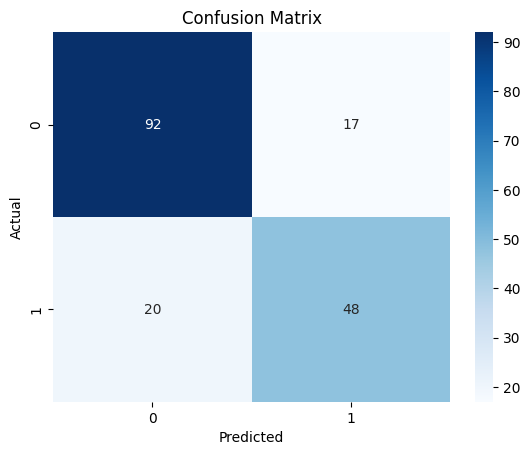

In [15]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Conclusion

---

Compared to the sklearn baseline from notebook 02, the NumPy implementation achieves similar behavior while exposing the internal training steps such as loss computation and gradient descent.